# Feature studies: compare a replica's features across fits

Loads **three fits** and compares, at the **same epoch** and for the **same
replica**, the **features** -- the eigenvectors $q^{(k)}$ of the matrix $H$
(the perp-projected NTK metric). A feature is a vector over $(\mathrm{flavour},
x)$, exactly like a PDF, so it is plotted value-vs-$x$, one figure per flavour,
with the three fits overlaid.

The features come from the `feature_grids_at_epoch` provider (the $q$ columns of
the NTK decomposition at one epoch); `plot_grids` then overlays them. One
comparison page (set of per-flavour figures) is produced per requested rank.

Note: building the decomposition runs at the chosen `EPOCH` only, but still
computes the NTK eigenvectors for that epoch, so it can be slow on the first call.

In [12]:
%matplotlib inline
from IPython.display import display
import pathlib

from matplotlib import pyplot as plt

# Importing the API first sets KERAS_BACKEND=jax (via ntkpdf/__init__.py).
from ntkpdf.api import API
from ntkpdf.plotting.pdfplots_providers import DEFAULT_FLAVOURS, DEFAULT_YLABELS
from ntkpdf.plotting.pdfplots_utils import plot_grids
from ntkpdf.plotting.style import make_figure, draw_line, HandlerSpec, LineHandler, OKABE_ITO, HandlerSpec, ComposedHandler
from ntkpdf.utils import EVOL_LIST

import logging
logging.basicConfig(level=logging.INFO)

In [13]:
# --- Talk / outreach style (LOCAL to this notebook) ------------------------
# Overrides the paper style from ntkpdf.plotting.style for a friendlier,
# projector-readable look on a single slide. This only mutates this kernel's
# rcParams -- style.py / the global NTKPDF_STYLE are untouched.
import matplotlib as mpl

TALK_STYLE = {
    # Warm, approachable sans-serif instead of the formal LaTeX serif.
    # mathtext still renders the $\Sigma$, $g$, ... labels nicely.
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "mathtext.fontset": "dejavusans",
    # Big type -- readable from the back of the room.
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 21,
    "legend.fontsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    # Open, airy frame: drop the top/right spines and the busy HEP minor ticks.
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.2,
    "xtick.top": False,
    "ytick.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.size": 5.0,
    "ytick.major.size": 5.0,
    # A soft guide grid instead of a dense boxed-in look.
    "axes.grid": True,
    "grid.color": "0.7",
    "grid.linewidth": 0.9,
    "grid.alpha": 0.7,
    # Bolder, rounded curves read better on a slide.
    "lines.linewidth": 3.0,
    "lines.markersize": 9.0,
    "lines.solid_capstyle": "round",
    "legend.frameon": False,
    # Transparent background so the coloured slide box shows through the plot
    # (matters for the saved SVGs; inline display still composites on white).
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.transparent": True,
}
mpl.rcParams.update(TALK_STYLE)

# NOTE: draw_line/draw_bounds in style.py hardcode linewidth=1.5, so bolder
# curves come from passing linewidth= through a plot's plot_args (see below).
TALK_LW = 2.5


In [14]:
SAVEPATH = pathlib.Path.cwd().parent / "figs" / "AI4science"
SAVEPATH.mkdir(parents=True, exist_ok=True)

In [15]:
# --- Edit these ---------------------------------------------------------
FIT = "260622-ac-02-ntk-sgd"
REPLICA = 3            # 1-based replica id (same replica across all fits)
# ------------------------------------------------------------------------

# Minimal data/theory context the FK / NTK chain needs.
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)

# Features

In [31]:
RANKS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
DEFAULT_YLABELS[1] = r"$q(x)$"
figs = API.plot_features_at_epoch_single_replica(fit=FIT,
                                                 **common_dict,
                                                 name="model",
                                                 epoch=15000,
                                                 flavours=DEFAULT_FLAVOURS,
                                                 ylabels=DEFAULT_YLABELS,
                                                 evol_fl_names=list(EVOL_LIST),
                                                 training=True,
                                                 rank_indices=RANKS,
                                                 replica_index=REPLICA,
                                                 plot_args=[{"linewidth": TALK_LW} for _ in RANKS],
                                                 legend_outside=True)

# Save the gluon
figs[1].savefig(SAVEPATH / "gluon_features.svg", bbox_inches="tight")

# Feature eigenvalues

In [36]:
# feature_eigvals = API.h_val_grid(fit=FIT,
#                                  **common_dict,
#                                  name="model",
#                                  training=True,
#                                  replica_index_list=tuple([3]),
# )
eigvals = API.eigenvalue_grid(fit="260622-ac-03-ntk-sgd", **common_dict, name="nn")

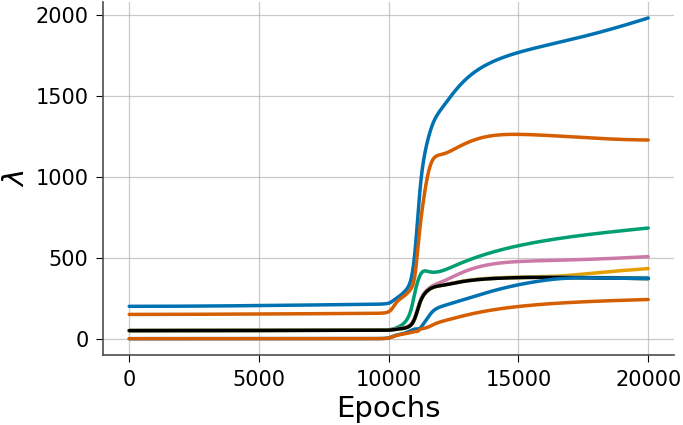

In [41]:
from colibri.ntk.ntkutils import NTKStats
fig, ax = make_figure()
N_EIG = 10
handles, labels = [], []

# Right axis: first N_EIG eigenvalues (one colour per rank), single replica.
for k in range(1, N_EIG + 1):
    stats = eigvals.get_plotting_data(rank_index=k)                 # (nreplicas, n_epochs)
    one = NTKStats(stats.data[[REPLICA - 1]])                        # single replica
    h = draw_line(ax, one, eigvals.xgrid, linestyle="-", linewidth=TALK_LW)
    handles.append(h)
    labels.append(eigvals.get_plotting_label(k))

# ax.set_yscale("log")
ax.set_xlabel("Epochs")
ax.set_ylabel(r"$\lambda$")

# Select a subset of x labels to avoid cluttering the x-axis
ax.set_xticks([0, 5000, 10000, 15000, 20000])
# ax.legend(handles=handles, labels=labels, handler_map={HandlerSpec: LineHandler()}, 
#           **{"loc": "upper right", "bbox_to_anchor": (1.01, 1.0)})

display(fig)
fig.savefig(SAVEPATH / "eigenvalues.svg", bbox_inches="tight")

# PDF

In [42]:
DEFAULT_YLABELS[1] = r"$f(x)$"
pdf = API.pdf_grid_at_epoch(fit=FIT, epoch=15000)
figs = list(
  plot_grids([pdf], 
             flavours=DEFAULT_FLAVOURS, 
             ylabels=DEFAULT_YLABELS,
             labels=["Output"],
             xscale="log", 
             plot_provider="line",
             plot_args=[{"replicas": [3], "linewidth": TALK_LW}]),
)
figs[1].savefig(SAVEPATH / "output_pdf.svg", bbox_inches="tight")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


# Loss

In [21]:
tr_grid, vl_grid = API.loss_function_grid(fit="260622-ac-03-ntk-sgd", **common_dict)

/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


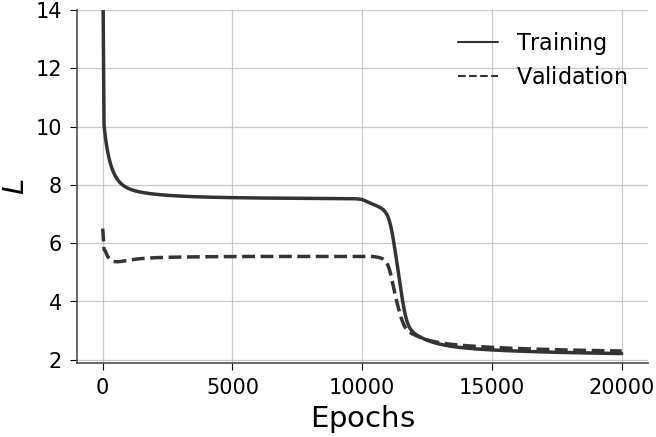

In [22]:
# Twin axis: left = loss, right = NTK eigenvalues. Both log scale.
fig, ax = make_figure()
handles, labels = [], []

# Left axis: this replica's training (solid) and validation (dashed) loss, grey.
tr_stats = tr_grid.get_plotting_data(replica_idx=REPLICA - 1)
vl_stats = vl_grid.get_plotting_data(replica_idx=REPLICA - 1)
draw_line(ax, tr_stats, tr_grid.xgrid, color="0.2", linestyle="-", linewidth=TALK_LW)
draw_line(ax, vl_stats, vl_grid.xgrid, color="0.2", linestyle="--", linewidth=TALK_LW)
handles += [HandlerSpec("0.2", None, "-", draw_box=False),
            HandlerSpec("0.2", None, "--", draw_box=False)]
labels += [r"$\rm Training$", r"$\rm Validation$"]

ax.set_ylim(1.9, 14)
ax.set_xlabel(tr_grid.xlabel)
ax.set_ylabel(r"$L$")
ax.set_xticks([0, 5000, 10000, 15000, 20000])

ax.legend(handles=handles, labels=labels, handler_map={HandlerSpec: LineHandler()})
display(fig)
fig.savefig(SAVEPATH/ "loss.svg", bbox_inches="tight")